<a href="https://colab.research.google.com/github/pmatkowska94/MSC_Data_Science/blob/main/CHO_EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.preprocessing import StandardScaler

In [ ]:
colours = {
    'hist_bar': '#4C9F70',
    'line_exp': '#1B9E77',
    'line_model': '#377EB8',
    'ci_fill': '#A6CEE3',
    'axes': '#333333',
    'grid': '#E5E5E5',
    'background': '#FFFFFF',
    'text': '#222222'
}

In [ ]:
plt.rcParams.update({
    'figure.facecolor': colours['background'],
    'axes.facecolor': colours['background'],
    'axes.edgecolor': colours['axes'],
    'axes.labelcolor': colours['text'],
    'xtick.color': colours['text'],
    'ytick.color': colours['text'],
    'grid.color': colours['grid'],
    'grid.linestyle': '--',
    'grid.linewidth': 0.8,
    'text.color': colours['text'],
    'axes.titlecolor': colours['text'],
})

In [ ]:
sns.set_style('whitegrid', {
    'axes.facecolor': '#FFFFFF',
    'grid.color': '#E5E5E5',
    'axes.edgecolor': '#333333',
    'text.color': '#222222'
})

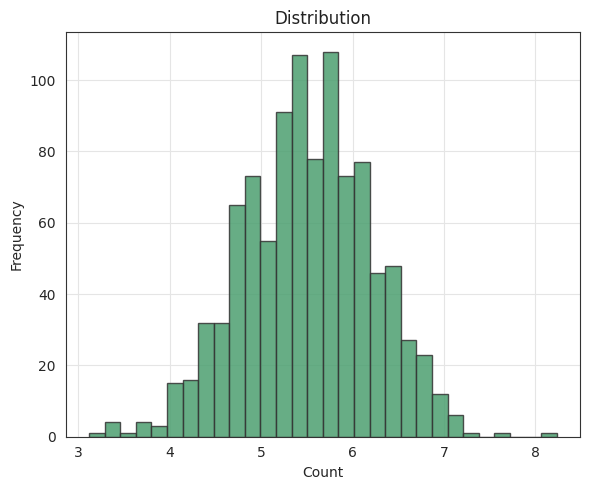

In [ ]:
data = np.random.normal(5.5, 0.7, 1000)

plt.figure(figsize=(6,5))
plt.hist(
    data,
    bins=30,
    color=colours['hist_bar'],
    edgecolor=colours['axes'],
    alpha=0.85,
    zorder=2
)
plt.xlabel('Count')
plt.ylabel('Frequency')
plt.title('Distribution')
plt.grid(True, zorder=0)
plt.tight_layout()

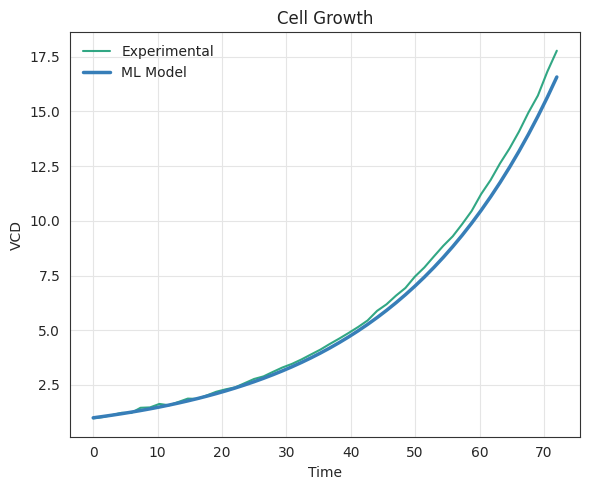

In [ ]:
time = np.linspace(0, 72, 50)
y_exp = np.exp(0.04 * time) + np.random.normal(0, 0.05, len(time))
y_model = np.exp(0.039 * time)

plt.figure(figsize=(6,5))
plt.plot(time, y_exp, color=colours['line_exp'], label='Experimental', alpha=0.9)
plt.plot(time, y_model, color=colours['line_model'], linewidth=2.5, label='ML Model')

plt.xlabel('Time')
plt.ylabel('VCD')
plt.title('Cell Growth')
plt.legend(frameon=False)
plt.grid(True)
plt.tight_layout()

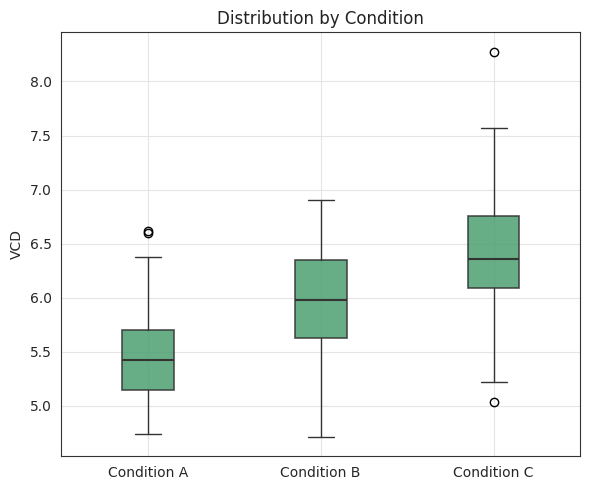

In [ ]:
data = [
    np.random.normal(5.5, 0.4, 100),
    np.random.normal(6.0, 0.5, 100),
    np.random.normal(6.4, 0.6, 100)
]
labels = ['Condition A', 'Condition B', 'Condition C']

fig, ax = plt.subplots(figsize=(6,5))
bp = ax.boxplot(
    data,
    patch_artist=True,
    medianprops=dict(color=colours['axes'], linewidth=1.5),
    whiskerprops=dict(color=colours['axes']),
    capprops=dict(color=colours['axes']),
    boxprops=dict(color=colours['axes'], linewidth=1.2),
)

for patch in bp['boxes']:
    patch.set_facecolor(colours['hist_bar'])
    patch.set_alpha(0.85)

ax.set_xticklabels(labels)
ax.set_ylabel('VCD')
ax.set_title('Distribution by Condition')
ax.grid(True, axis='y')
plt.tight_layout()

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving CSV Data Main Study.csv to CSV Data Main Study.csv


In [ ]:
df = pd.read_csv('CSV Data Main Study.csv')
df.head()

,Vessel,Process_ID,Run_ID,Clone_ID,time [day],VCD [10 ^6 cells/mL],Volume [L],Agitation [rpm],P/V [W/m^3],VVM (air/max_vol),...,impeller diameter [cm],Tip speed [m/s],Reynolds,Aspect_ratio,DO [%],Np,Number of impellers,group_volume,Seeding density [10^6 cells/mL],cell_type
0,ambr 15,1,1,1,0.0,0.41,15.0,1200.0,220.8,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.015,0.41,cho
1,ambr 15,1,1,1,1.0,2.67,15.0,1200.0,220.8,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.015,0.41,cho
2,ambr 15,1,1,1,2.0,4.88,15.0,1200.0,220.8,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.015,0.41,cho
3,ambr 15,1,1,1,3.0,7.09,15.0,1200.0,220.8,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.015,0.41,cho
4,ambr 15,1,1,1,4.0,11.16,15.0,1200.0,220.8,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.015,0.41,cho


In [ ]:
df.rename(columns={
    'Vessel': 'vessel',
    'Process_ID': 'p_id',
    'Run_ID' : 'r_id',
    'Clone_ID': 'clone_id',
    'time [day]': 'time',
    'VCD [10 ^6 cells/mL]': 'vcd',
    'Volume [L]': 'volume',
    'Agitation [rpm]': 'agitation',
    'P/V [W/m^3]': 'p_v',
    'VVM (air/max_vol)': 'vvm',
    'kLa [1/h]': 'kla',
    'impeller diameter [cm]': 'impeller_d',
    'Tip speed [m/s]': 'tip_speed',
    'Aspect_ratio': 'aspect_r',
    'DO [%]': 'do',
    'Reynolds': 'reynolds',
    'Np' : 'np',
    'Number of impellers' : 'impeller_no',
    'Seeding density [10^6 cells/mL]' : 'seed_d'
}, inplace=True)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1745 entries, 0 to 1744
Data columns (total 21 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   vessel        1726 non-null   object 
 1   p_id          1745 non-null   int64  
 2   r_id          1745 non-null   int64  
 3   clone_id      1745 non-null   int64  
 4   time          1715 non-null   float64
 5   vcd           1586 non-null   float64
 6   volume        1602 non-null   float64
 7   agitation     1632 non-null   float64
 8   p_v           1677 non-null   float64
 9   vvm           1033 non-null   float64
 10  kla           533 non-null    float64
 11  impeller_d    1588 non-null   float64
 12  tip_speed     1588 non-null   float64
 13  reynolds      1588 non-null   float64
 14  aspect_r      1478 non-null   float64
 15  do            1532 non-null   float64
 16  np            842 non-null    float64
 17  impeller_no   788 non-null    float64
 18  group_volume  1745 non-null 

All importnat variables are float. Categorical are int. Vessel describes name of the vessel.


There are some missing values. kla, np, and impeller_no represents the most NaN

In [ ]:
df.describe()

,p_id,r_id,clone_id,time,vcd,volume,agitation,p_v,vvm,kla,impeller_d,tip_speed,reynolds,aspect_r,do,np,impeller_no,group_volume,seed_d
count,1745.000000,1745.000000,1745.000000,1715.000000,1586.000000,1602.000000,1632.000000,1677.000000,1033.000000,533.000000,1588.000000,1588.000000,1588.000000,1478.000000,1532.000000,842.000000,788.000000,1745.000000,1649.000000
mean,11.868195,1.310602,17.022350,6.975990,12.089990,574.947333,178.332972,38.172810,0.224113,8.784109,19.238904,0.972817,97080.948979,2.062158,40.274151,1.444192,2.159898,572.593066,0.590085
std,8.523163,0.692213,10.549037,4.367582,9.146432,1235.402537,174.233412,50.244726,1.983687,13.983003,17.595843,0.448493,126736.953808,0.456757,8.165693,0.555612,0.800137,1277.181876,0.385537
min,1.000000,1.000000,1.000000,-0.060700,0.152131,0.015000,26.000000,1.200000,0.000000,0.650000,1.100000,0.293200,3638.000000,1.000000,30.000000,0.350000,1.000000,0.015000,0.150000
25%,4.000000,1.000000,7.000000,3.002325,4.702829,3.000000,88.400000,13.380000,0.008000,0.900000,6.980000,0.681000,18459.000000,1.800000,40.000000,1.240000,1.000000,3.000000,0.300000
50%,10.000000,1.000000,17.000000,6.990981,10.715806,50.000000,130.000000,30.000000,0.010000,2.400000,10.860000,0.864435,40737.000000,2.000000,40.000000,1.240000,2.000000,50.000000,0.500000
75%,20.000000,1.000000,27.000000,10.857121,17.815357,439.568000,200.000000,40.000000,0.025000,8.000000,22.970000,1.252000,122007.750000,2.500000,40.000000,2.100000,3.000000,500.000000,0.700000
max,26.000000,5.000000,33.000000,19.000000,47.528868,5051.800000,1200.000000,429.000000,28.122502,40.000000,89.760000,2.618000,762006.050000,3.000000,60.000000,2.600000,3.000000,5000.000000,2.900000


There are 26 processes using 33 CHO cell clones. Processer are different length between [0, 19]. Str volume ranges between [0.015, 5000] L.

In [ ]:
df.nunique()

,0
vessel,63
p_id,26
r_id,5
clone_id,33
time,1160
vcd,1323
volume,375
agitation,166
p_v,338
vvm,105


In [ ]:
df.isnull().sum()

,0
vessel,19
p_id,0
r_id,0
clone_id,0
time,30
vcd,159
volume,143
agitation,113
p_v,68
vvm,712


<Axes: >

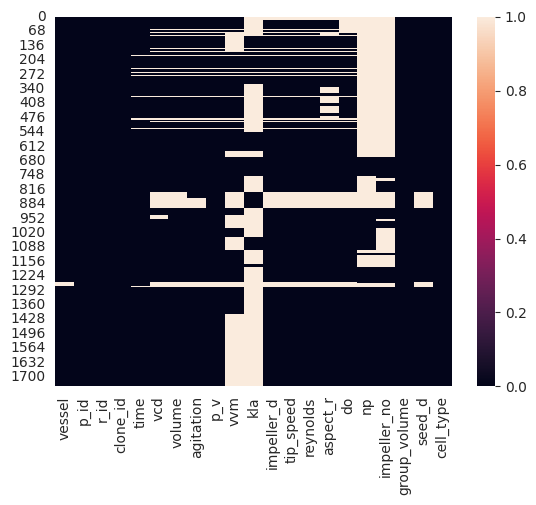

In [ ]:
sns.heatmap(df.isnull())

**Missing Values:**

kla > 50 % will be dropped from dataset

np and impeller_no are variables used for engineering features but irrelevant in the dataset, will be dropped

critical information missing: time, vcd, volume will be dropped

vvm is important and will be imputed

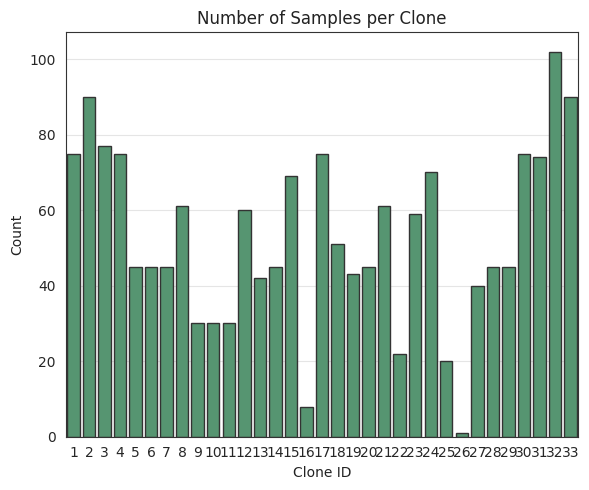

In [ ]:
plt.figure(figsize=(6,5))
sns.countplot(
    x='clone_id',
    data=df,
    color=colours['hist_bar'],
    edgecolor=colours['axes']
)
plt.xlabel('Clone ID', color=colours['text'])
plt.ylabel('Count', color=colours['text'])
plt.title('Number of Samples per Clone', color=colours['text'])
plt.grid(True, axis='y', color=colours['grid'], linewidth=0.8)
plt.tight_layout()

**Length of process for each clone:** There are some clones that were used for longer scale up process. There are some clones used less than 20 times, which could be very short process or related to other missing values.

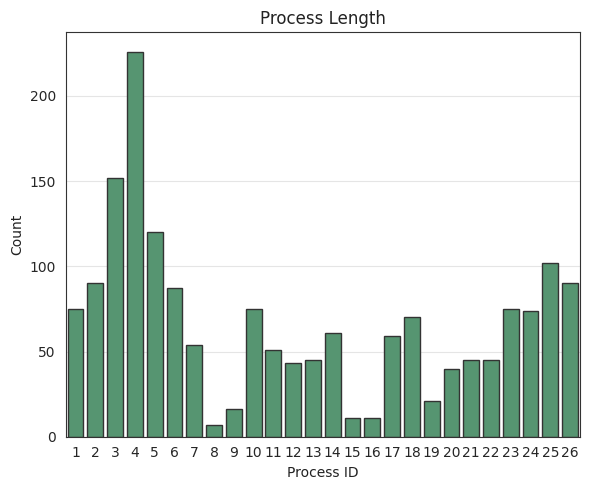

In [ ]:
plt.figure(figsize=(6, 5))
sns.countplot(
    x='p_id',
    data=df,
    color=colours['hist_bar'],
    edgecolor=colours['axes']
)
plt.xlabel('Process ID', color=colours['text'])
plt.ylabel('Count', color=colours['text'])
plt.title('Process Length', color=colours['text'])
plt.grid(True, axis='y', color=colours['grid'], linewidth=0.8)
plt.tight_layout()

**Lenght of the processes:** some processes represent a long scale up. Some are very short representing probably a run on one scale.

In [ ]:
pd.crosstab(df['p_id'], df['clone_id'])

clone_id,1,2,3,4,5,6,7,8,9,10,...,24,25,26,27,28,29,30,31,32,33
p_id,,,,,,,,,,,,,,,,,,,,,
1,75,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,90,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,77,75,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,45,45,45,61,30,0,...,0,0,0,0,0,0,0,0,0,0
5,0,0,0,0,0,0,0,0,0,30,...,0,0,0,0,0,0,0,0,0,0
6,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
7,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
8,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
9,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


**How much clones per process:** some processes run with only one CHO clone, some with different ones.

In [ ]:
pd.crosstab(df['p_id'], df['group_volume'])

group_volume,0.015,0.250,1.000,1.300,2.000,3.000,5.000,10.000,14.000,15.000,50.000,80.000,100.000,200.000,250.000,500.000,1000.000,2000.000,5000.000
p_id,,,,,,,,,,,,,,,,,,,
1,15,0,0,0,0,0,0,15,0,0,15,0,0,15,0,0,15,0,0
2,15,15,0,0,0,0,15,0,0,0,15,0,0,15,0,0,0,15,0
3,0,89,0,0,0,0,30,0,0,0,0,0,0,0,33,0,0,0,0
4,0,0,0,0,0,75,0,0,0,0,0,0,0,15,0,75,0,61,0
5,0,0,0,0,60,45,0,0,0,0,15,0,0,0,0,0,0,0,0
6,0,0,0,0,0,0,0,0,0,0,30,0,0,0,0,30,0,0,27
7,0,0,0,41,0,0,0,0,13,0,0,0,0,0,0,0,0,0,0
8,0,0,0,7,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
9,0,0,0,16,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


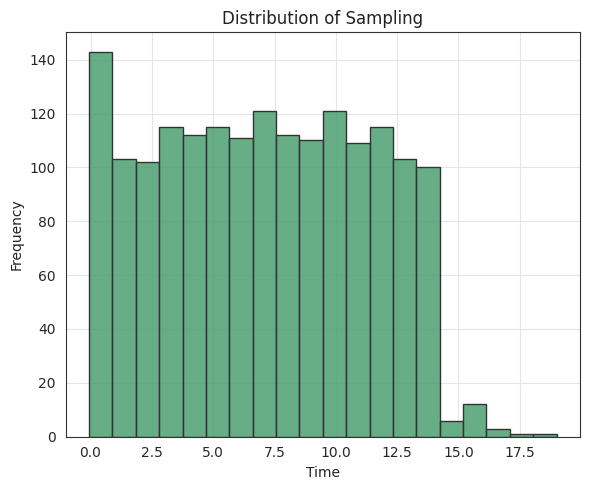

In [ ]:
plt.figure(figsize=(6,5))
sns.histplot(
    df['time'],
    bins=20,
    color=colours['hist_bar'],
    edgecolor=colours['axes'],
    alpha=0.85
)
plt.xlabel('Time', color=colours['text'])
plt.ylabel('Frequency', color=colours['text'])
plt.title('Distribution of Sampling', color=colours['text'])
plt.grid(True, axis='y', color=colours['grid'], linewidth=0.8)
plt.tight_layout()

**Sampling distribution:** Sampling was done everyday for almost all processes, as the sampling  distribution looks consistent. Some processes are longer than usual.

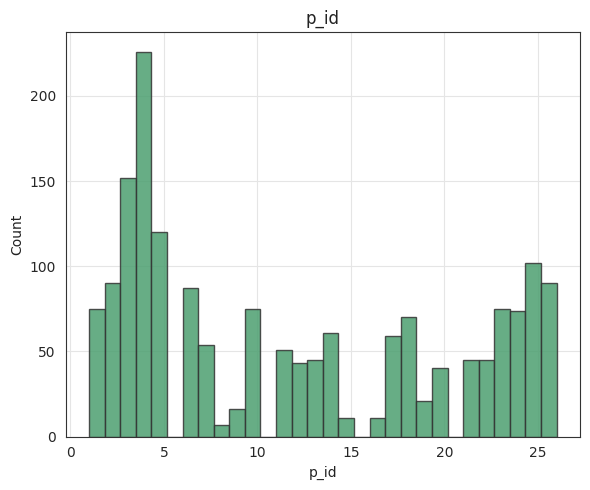

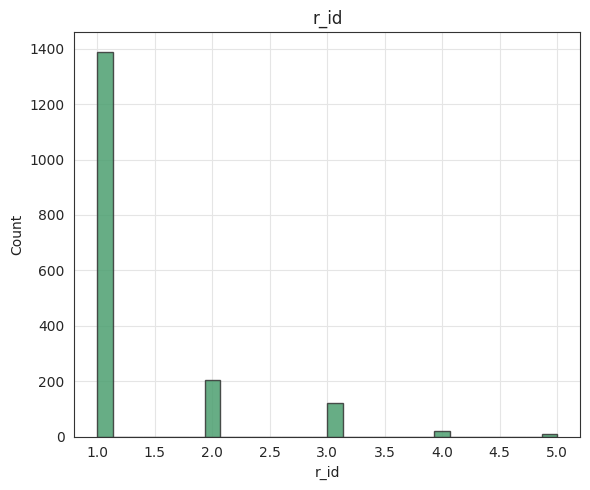

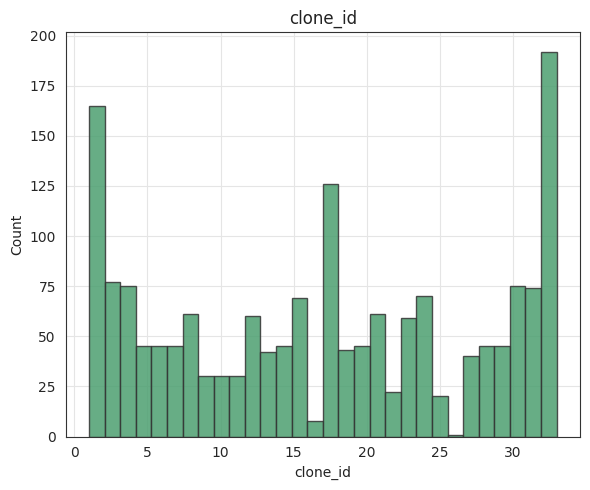

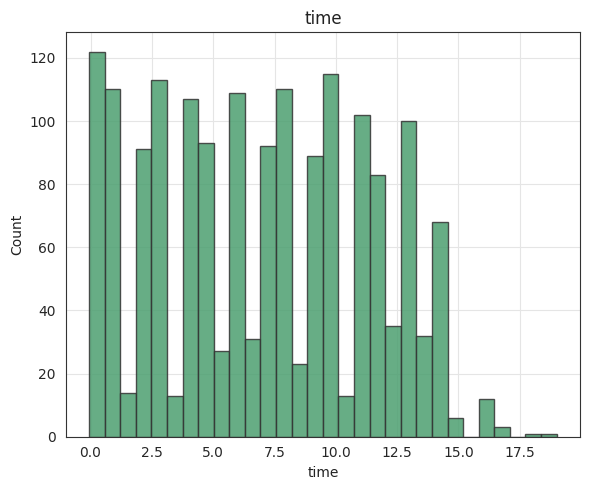

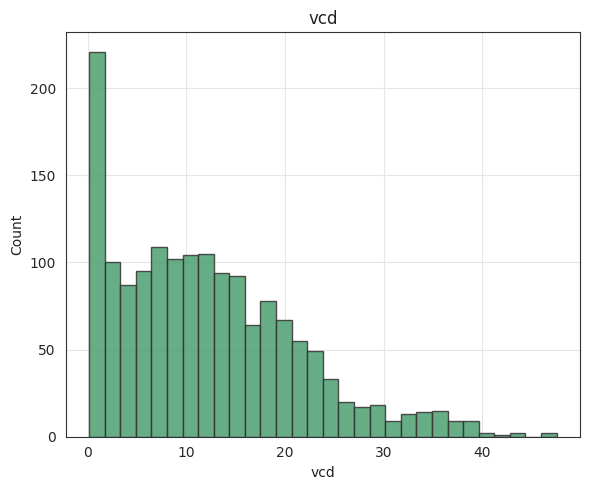

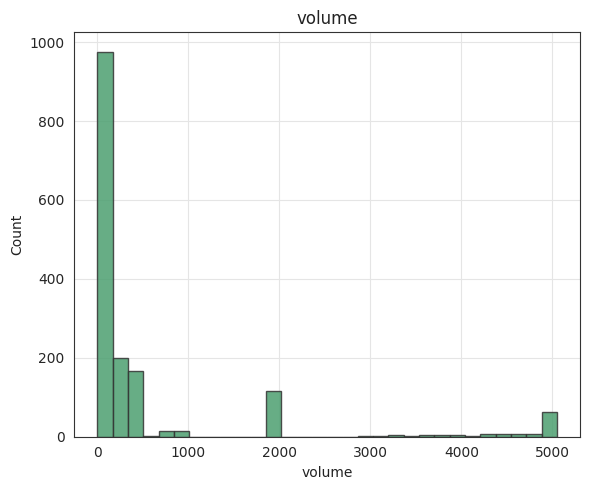

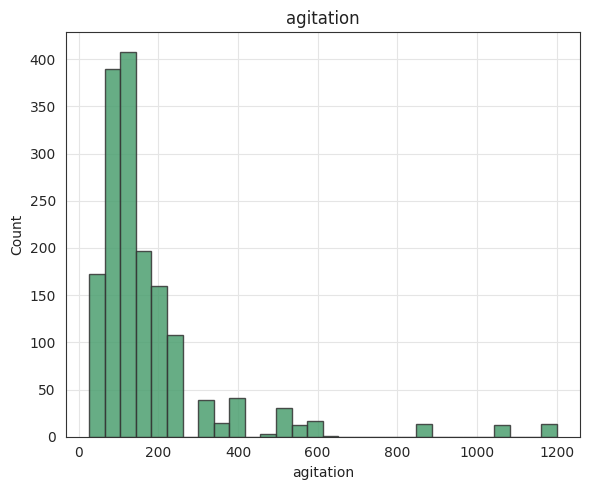

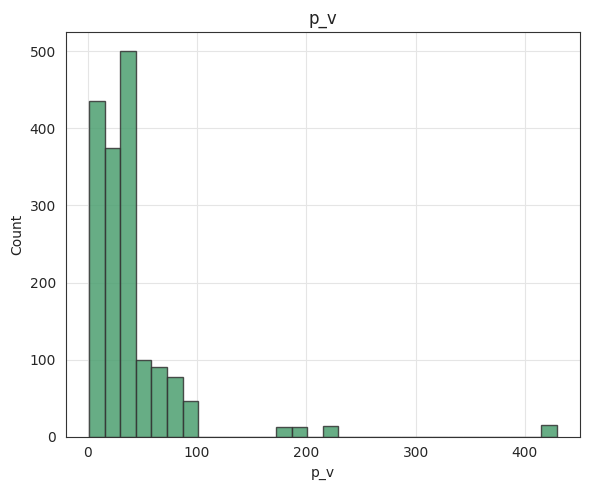

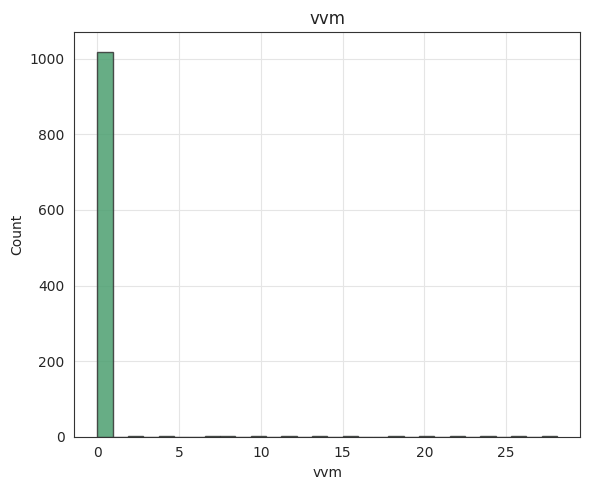

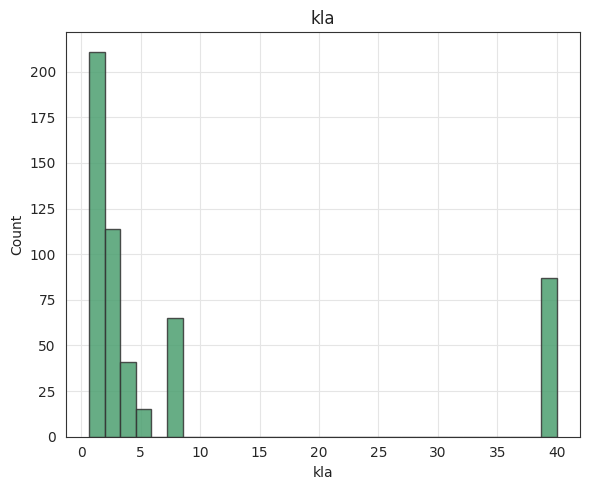

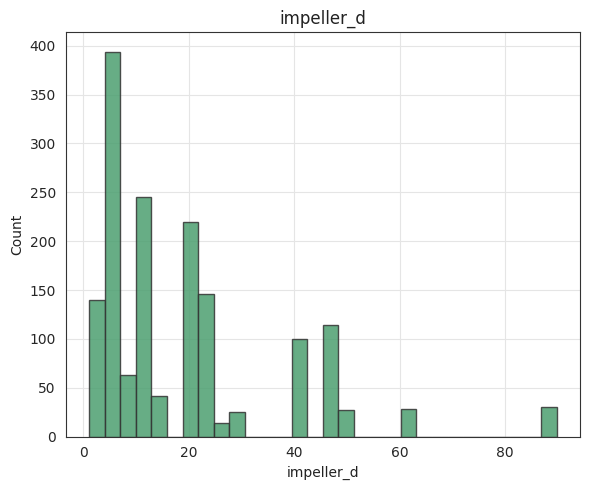

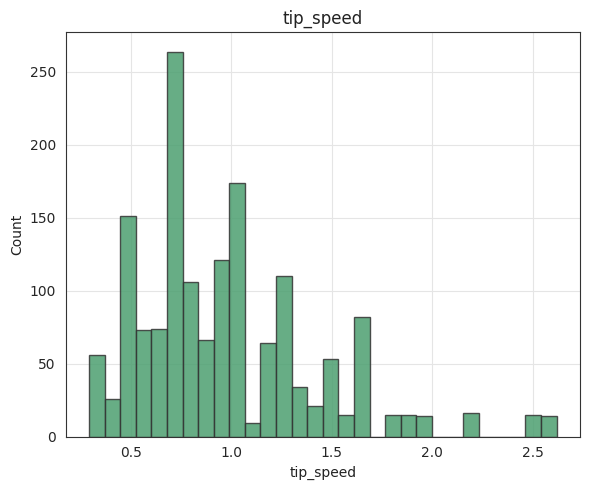

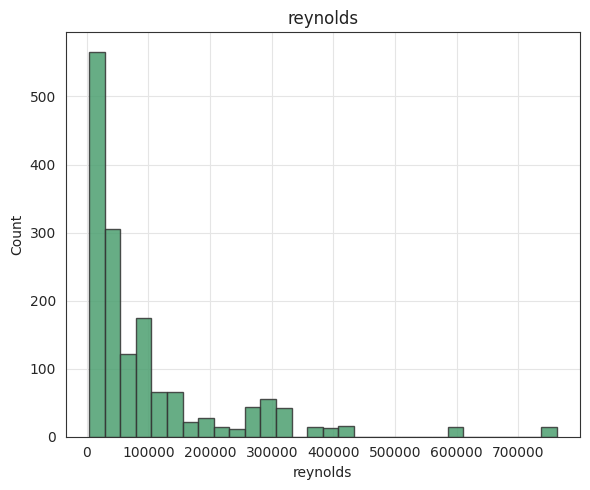

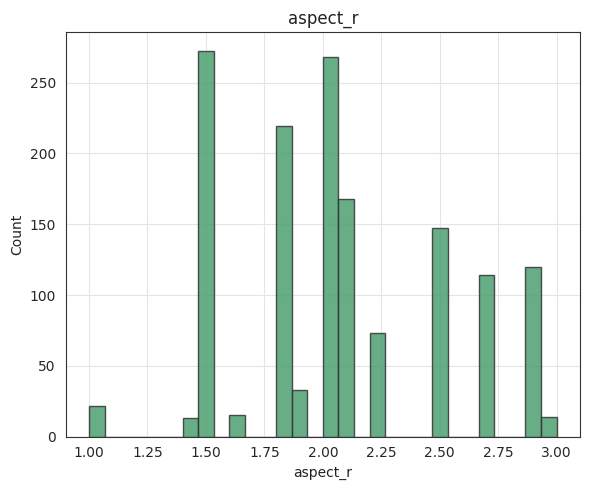

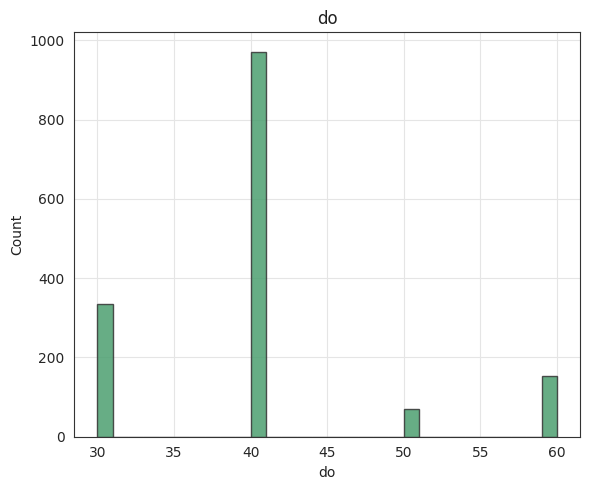

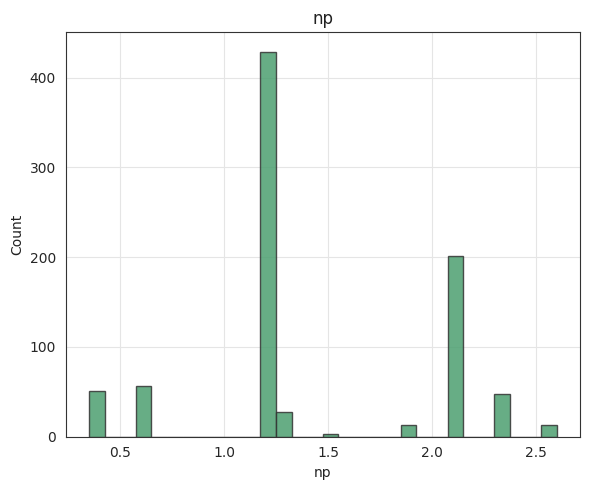

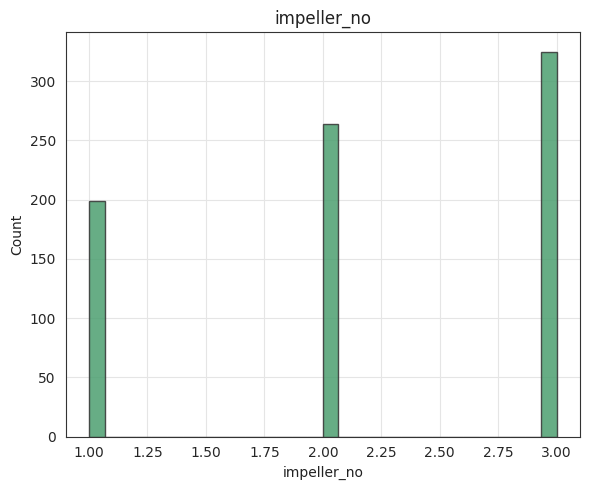

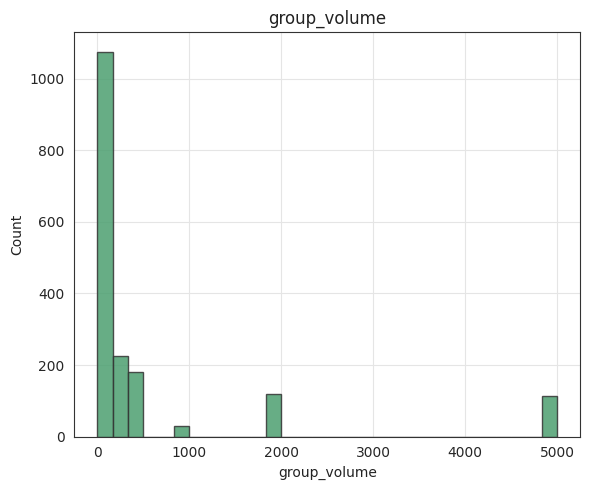

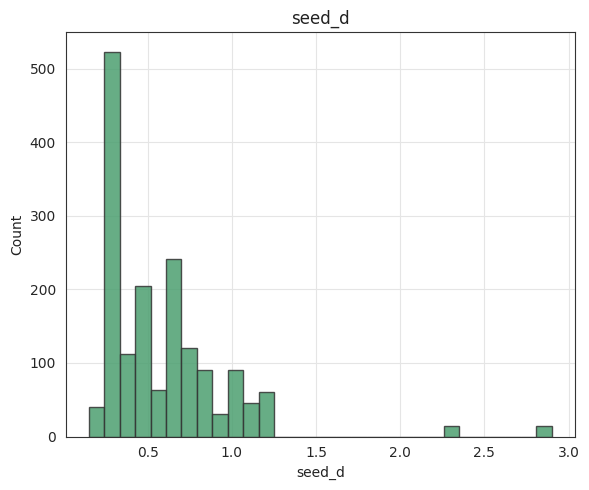

In [ ]:
for column in df.select_dtypes(include='number').columns:
    plt.figure(figsize=(6, 5))
    plt.hist(df[column].dropna(),
        bins=30,
        color=colours['hist_bar'],
        edgecolor=colours['axes'],
        alpha=0.85
    )
    plt.title(f'{column}', color=colours['text'])
    plt.xlabel(column, color=colours['text'])
    plt.ylabel('Count', color=colours['text'])
    plt.grid(True, axis='y', color=colours['grid'])
    plt.tight_layout()

**Distribution of all colums:**

VCD values are evenly distributed with a pronounced peak around 0-1, consistent with typical seeding densities for most processes.There are some Clones showing very high VCD.

The dataset includes more observations from small-scale experiments.

Agitation speed ranges from ~30 to 300rpm, which matches realistic bioprocess operating conditions. Values exceeding 300rpm likely correspond to very small-scale systems (e.g., 15mL), and could be considered outliers, as such high speeds would cause excessive shear stress in larger scales. The same consideration applies to P/V values, which are mathematically related.

VVM values range from 0.00 to 1 indicating low aeration rates for small scale which is consistent with the amount of small scale experiments in the dataset.


kLa values also show no significant outliers, as the numbers are biologically meaningful.

Impeller diameter distribution mirrors that of volume, confirming that small-scale vessels were used more frequently. Tip speed distribution closely follows agitation speed, which is consistent with physical expectations.


Aspect ratio ranges between 1.0 and 3.0, which is realistic for bioreactors.

DO values are typical setpoints in bioprocess control.

Np and number of impellers do not show any outliers.

There are some very high unusual seeding densities.



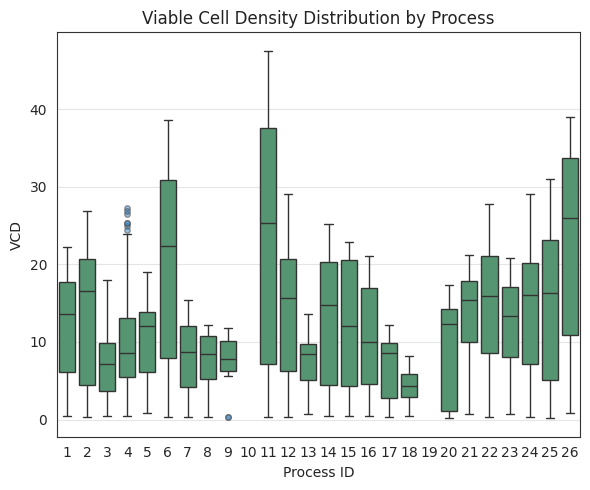

In [ ]:
plt.figure(figsize=(6,5))
sns.boxplot(
    x='p_id',
    y='vcd',
    data=df,
    color=colours['hist_bar'],
    boxprops=dict(edgecolor=colours['axes']),
    medianprops=dict(color=colours['axes']),
    whiskerprops=dict(color=colours['axes']),
    capprops=dict(color=colours['axes']),
    flierprops=dict(marker='o', markerfacecolor=colours['line_model'], alpha=0.5, markersize=4)
)
plt.xlabel('Process ID', color=colours['text'])
plt.ylabel('VCD', color=colours['text'])
plt.title('Viable Cell Density Distribution by Process', color=colours['text'])
plt.grid(True, axis='y', color=colours['grid'], linewidth=0.8)
plt.tight_layout()

**Boxplot of the distribution of VCD:** VCD varies widely between processes, with some (like 6, 11, and 26) showing higher median values and variability, while others (like 8 and 18) have lower and more consistent VCD levels. Outliers appear in several processes, indicating occasional extreme values.

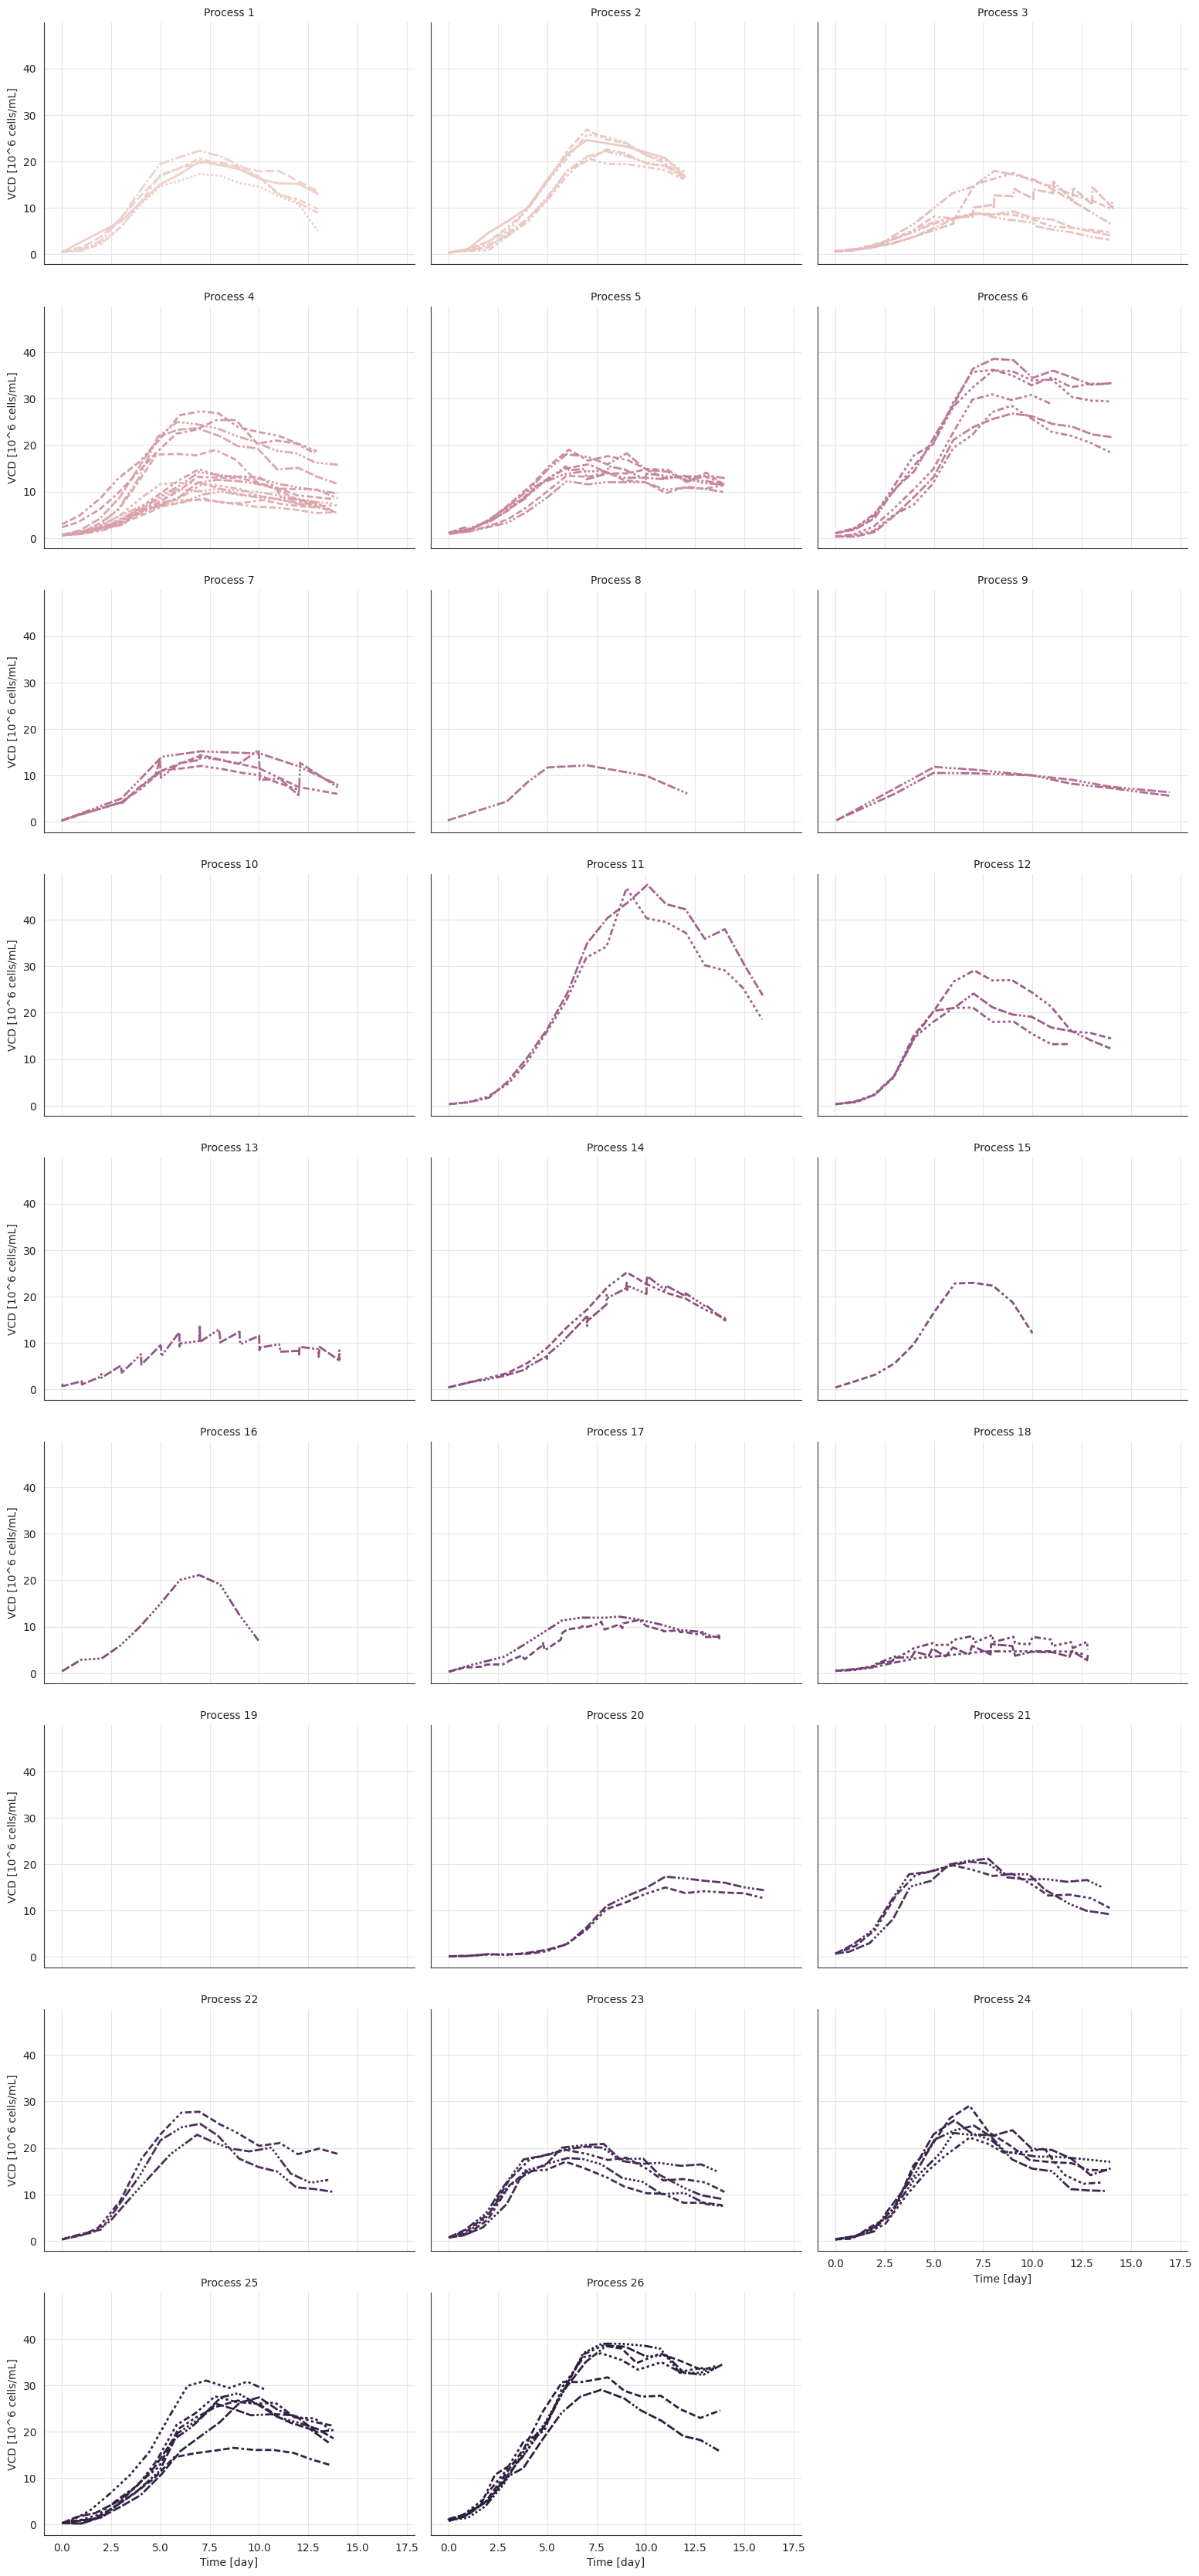

In [ ]:
df_sorted = df.sort_values(
    ['p_id', 'clone_id', 'r_id', 'group_volume'],
    ascending=True
).copy()

grid = sns.relplot(
    data=df_sorted,
    x='time', y='vcd',
    hue='clone_id',
    style='vessel',
    kind='line',
    col='p_id',
    col_wrap=3,
    linewidth=2,
    height=4, aspect=1.3,
    errorbar=None
)
grid.set_axis_labels('Time [day]', 'VCD [10^6 cells/mL]')
grid.set_titles('Process {col_name}')

for ax in grid.axes.flatten():
    ax.grid(True, color=colours['grid'], linewidth=0.8)
    ax.tick_params(colors=colours['text'])
    ax.set_facecolor(colours['background'])

grid.fig.subplots_adjust(top=0.92, right=0.85)
grid._legend.remove()

**Growth Curves:** The growth curves across all 26 processes are consistent and reproducible. The overall profiles display the expected pattern of exponential cell growth followed by a stationary phase, with similar maximum VCD levels and growth durations across most processes. Minor variations between clones and vessels are visible, reflecting normal biological and process variability.

Text(0.5, 1.0, 'Correlation Heatmap')

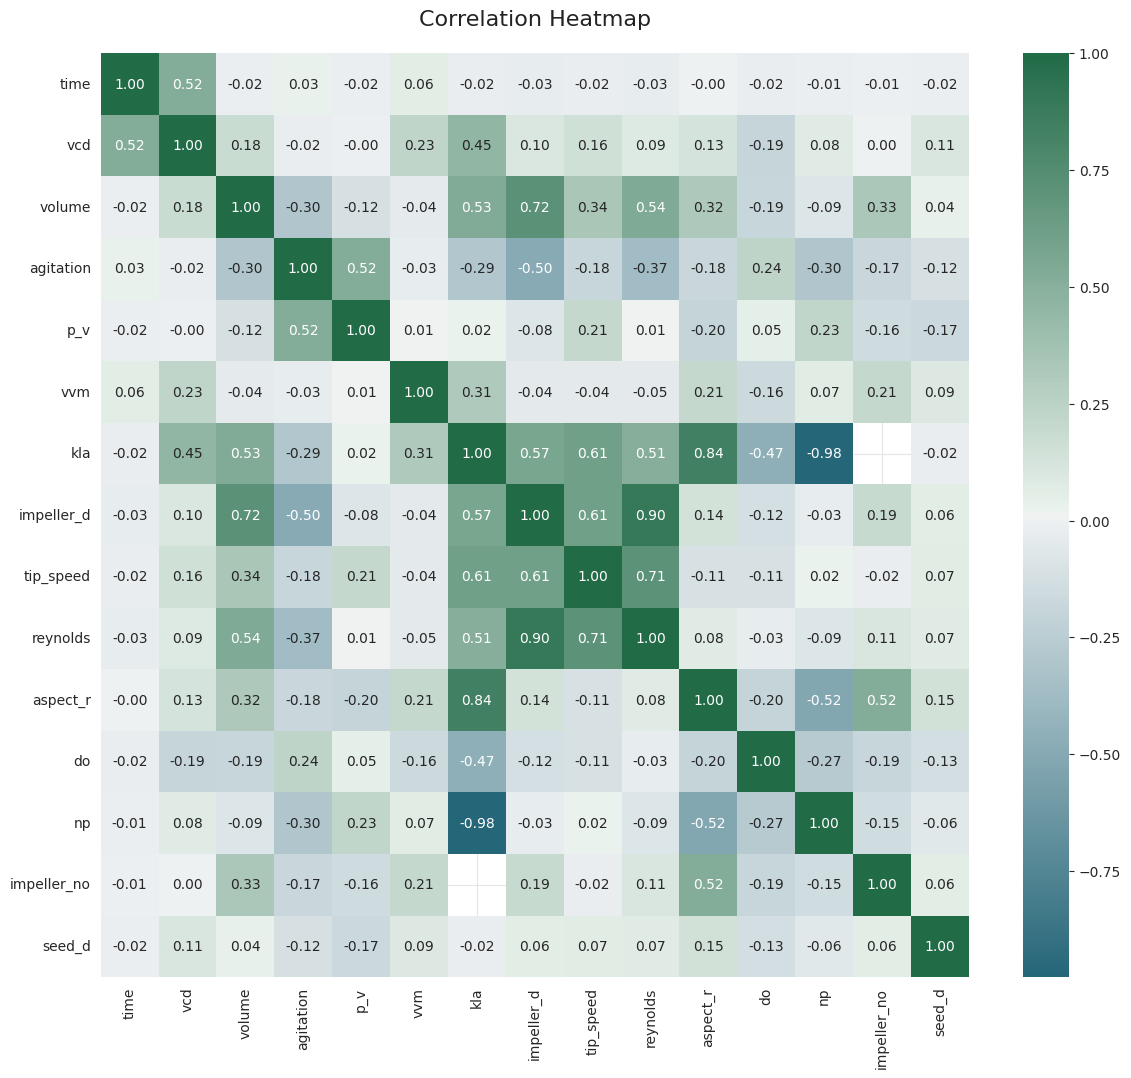

In [ ]:
numeric_df = df.select_dtypes(include=['number']).drop(columns=['p_id', 'clone_id', 'group_volume', 'r_id' ])
corr = numeric_df.corr()
plt.figure(figsize=(14, 12))
sns.heatmap(
    corr,
    cmap=sns.diverging_palette(220, 145, s=85, l=40, as_cmap=True),
    annot=True,
    fmt='.2f'
)
plt.title('Correlation Heatmap', fontsize=16, pad=20)

**Correlation matrix:** A strong correlation is visible among variables that are mathematically dependent, such as impeller diameter and Reynolds number or tip speed. Another notable relationship can be observed between vessel volume (representing the scale of the STR) and scale-dependent geometrical parameters, including impeller diameter.

The variable k<sub>L</sub>a shows a strong correlation with both the aspect ratio and the impeller’s power number, which aligns with the physical principles governing STR hydrodynamics and oxygen transfer. Additionally, k<sub>L</sub>a correlates with DO, as improved oxygen transfer enhances the ability to reach higher DO setpoints; however, DO itself represents only a controlled setpoint rather than a process response.

A further observation is the strong correlation between the aspect ratio (defined as working volume height to diameter) and the number of impellers. This may be attributed to the fact that taller vessels or those designed for higher working volumes typically require multiple impellers to ensure effective mixing and mass transfer

**Data splitting**

~70 % of (p_id, clone_id, run_id, group_volume) grouped processes for train.

~15% for validation.

~15% for test

Evaluation to measure both interpolation (within 15 mL–2000 L) and extrapolation (to 5000 L).

In [ ]:
pairs = (df[['clone_id', 'group_volume']]
         .drop_duplicates()
         .sort_values(['clone_id', 'group_volume'])
         .reset_index(drop=True))

print(pairs)

    clone_id  group_volume
0          1         0.015
1          1        10.000
2          1        50.000
3          1       200.000
4          1      1000.000
..       ...           ...
90        33        50.000
91        33       200.000
92        33       500.000
93        33      2000.000
94        33      5000.000

[95 rows x 2 columns]


In [ ]:
print(pairs.groupby('clone_id')['group_volume'].nunique())

clone_id
1     5
2     6
3     3
4     3
5     3
6     3
7     3
8     4
9     2
10    2
11    2
12    3
13    3
14    3
15    2
16    1
17    3
18    3
19    3
20    1
21    2
22    1
23    2
24    3
25    1
26    1
27    2
28    3
29    3
30    4
31    4
32    6
33    5
Name: group_volume, dtype: int64


In [ ]:
ID_pairs  = pairs[pairs['group_volume'] <= 2000].copy()
OOD_pairs = pairs[(pairs['group_volume'] > 2000) & (pairs['group_volume'] <= 5000)].copy()

In [ ]:
frac_train = 0.7
min_train = 1
train_list = []

In [ ]:
def n_train(n):
    if n == 1:
        return 1
    t = max(min_train, math.ceil(n * frac_train))
    return min(t, n - 1)

In [ ]:
import math
for cid, g in pairs.groupby('clone_id'):
    vols = g['group_volume'].sort_values().to_numpy()
    t = n_train(len(vols))
    chosen = vols[:t]

    train_list.append(pd.DataFrame({
        'clone_id': cid,
        'group_volume': chosen
    }))

In [ ]:
train_pairs = pd.concat(train_list, ignore_index=True)

In [ ]:
print(train_pairs)

    clone_id  group_volume
0          1         0.015
1          1        10.000
2          1        50.000
3          1       200.000
4          2         0.015
..       ...           ...
62        32      2000.000
63        33        50.000
64        33       200.000
65        33       500.000
66        33      2000.000

[67 rows x 2 columns]


In [ ]:
holdout_ID = (ID_pairs.merge(train_pairs, on=['clone_id','group_volume'], how='left', indicator=True))
holdout_ID = holdout_ID[holdout_ID['_merge']=='left_only'][['clone_id','group_volume']]
holdout_ID = holdout_ID.sample(frac=1, random_state=42).reset_index(drop=True)

In [ ]:
n_ID = len(ID_pairs)
target_val_pairs  = max(0, int(round(0.15 * n_ID)))
target_test_pairs = max(0, int(round(0.15 * n_ID)))

In [ ]:
if len(holdout_ID) < (target_val_pairs + target_test_pairs):
    split_idx = len(holdout_ID) // 2
else:
    split_idx = target_val_pairs

val_pairs  = holdout_ID.iloc[:split_idx]
test_in_pairs = holdout_ID.iloc[split_idx:split_idx + target_test_pairs]

In [ ]:
test_pairs = pd.concat([test_in_pairs, OOD_pairs], ignore_index=True).drop_duplicates()

In [ ]:
train_df = df.merge(train_pairs, on=['clone_id','group_volume'], how='inner')
val_df   = df.merge(val_pairs,   on=['clone_id','group_volume'], how='inner')
test_df  = df.merge(test_pairs,  on=['clone_id','group_volume'], how='inner')

In [ ]:
train_df.describe()

,p_id,r_id,clone_id,time,vcd,volume,agitation,p_v,vvm,kla,impeller_d,tip_speed,reynolds,aspect_r,do,np,impeller_no,group_volume,seed_d
count,1291.000000,1291.000000,1291.000000,1264.000000,1169.000000,1169.000000,1199.000000,1229.000000,765.000000,353.000000,1155.000000,1155.000000,1155.000000,1088.000000,1113.000000,614.000000,608.000000,1291.000000,1210.000000
mean,12.134005,1.337723,17.238575,7.006458,12.069366,177.438242,207.355713,39.778546,0.297582,9.101926,14.076087,0.929410,66812.250677,2.052233,40.664870,1.404479,1.968750,173.735786,0.567541
std,8.728631,0.691450,10.817031,4.392346,9.230549,394.495413,192.624904,56.512720,2.300980,14.197804,10.729775,0.411218,80332.630642,0.442445,8.487612,0.552231,0.789559,381.728108,0.322822
min,1.000000,1.000000,1.000000,-0.060700,0.152131,0.015000,60.000000,1.200000,0.000000,0.700000,1.100000,0.293200,3638.000000,1.000000,30.000000,0.350000,1.000000,0.015000,0.150000
25%,4.000000,1.000000,7.000000,3.015541,4.860335,2.000000,106.500000,13.380000,0.005000,1.000000,5.800000,0.681000,13867.500000,1.800000,40.000000,1.240000,1.000000,2.000000,0.300000
50%,10.000000,1.000000,17.000000,6.990981,10.507009,35.572369,140.000000,30.000000,0.010000,2.000000,10.860000,0.830000,35360.000000,2.000000,40.000000,1.240000,2.000000,15.000000,0.500000
75%,21.000000,1.000000,28.000000,10.911625,17.765363,200.000000,203.000000,38.230000,0.035000,8.000000,20.320000,1.200000,87112.000000,2.250000,40.000000,2.100000,3.000000,200.000000,0.700000
max,26.000000,5.000000,33.000000,19.000000,47.528868,2000.000000,1200.000000,429.000000,28.122502,40.000000,42.000000,2.529000,378748.000000,2.900000,60.000000,2.600000,3.000000,2000.000000,2.300000


Training dataset (70%) contains data about all clones with volumes between 15 mL and 2000L.

In [ ]:
val_df.describe()

,p_id,r_id,clone_id,time,vcd,volume,agitation,p_v,vvm,kla,impeller_d,tip_speed,reynolds,aspect_r,do,np,impeller_no,group_volume,seed_d
count,181.000000,181.000000,181.000000,178.000000,175.000000,175.000000,175.000000,175.000000,84.000000,90.000000,175.000000,175.000000,175.000000,162.000000,161.000000,77.000000,29.000000,181.000000,181.000000
mean,8.988950,1.419890,13.596685,6.786118,11.402486,528.082286,117.680000,45.589257,0.016476,2.780000,24.343943,1.155920,156705.443631,1.935432,40.683230,1.748052,2.482759,580.441989,0.724862
std,6.050701,0.907035,8.439839,4.148370,7.954227,692.479333,51.777712,28.483681,0.005152,2.685215,17.417966,0.593365,170668.134143,0.408983,7.674977,0.760334,0.508548,721.429194,0.697807
min,1.000000,1.000000,1.000000,-0.060700,0.290000,3.500000,30.000000,8.000000,0.010000,0.650000,7.670000,0.470000,18952.541970,1.500000,30.000000,0.400000,2.000000,5.000000,0.290000
25%,4.000000,1.000000,6.000000,3.002826,4.330676,4.250000,100.000000,16.355000,0.010000,0.650000,8.890000,0.650000,26533.558750,1.800000,40.000000,1.240000,2.000000,5.000000,0.450000
50%,12.000000,1.000000,19.000000,6.995674,11.108273,239.300000,121.000000,37.250000,0.017500,0.650000,20.000000,0.960000,75657.000000,1.850000,40.000000,2.300000,2.000000,250.000000,0.450000
75%,14.000000,1.000000,21.000000,10.059347,18.019512,800.000000,140.000000,79.700000,0.020000,5.000000,30.480000,1.277600,187354.000000,1.900000,40.000000,2.300000,3.000000,1000.000000,0.630000
max,18.000000,4.000000,24.000000,14.033288,29.088714,2000.000000,260.000000,85.000000,0.023500,8.000000,61.110000,2.618000,595000.000000,3.000000,60.000000,2.300000,3.000000,2000.000000,2.900000


Val dataset (15%) contains data about not all clones, V between 3.5 and 2000L.

In [ ]:
test_df.describe()

,p_id,r_id,clone_id,time,vcd,volume,agitation,p_v,vvm,kla,impeller_d,tip_speed,reynolds,aspect_r,do,np,impeller_no,group_volume,seed_d
count,273.000000,273.000000,273.000000,273.000000,242.000000,258.000000,258.000000,273.000000,184.000000,90.000000,258.000000,258.000000,258.000000,228.000000,258.000000,151.000000,151.000000,273.000000,258.000000
mean,12.520147,1.109890,18.271062,6.958720,12.686780,2407.852412,84.596550,26.189926,0.013448,13.541667,38.888798,1.042938,192143.196947,2.199561,38.333333,1.450728,2.867550,2453.560440,0.601260
std,8.598508,0.456583,10.092211,4.404013,9.532915,2093.536369,51.233026,20.660421,0.007831,17.451291,25.775491,0.456267,186756.095553,0.520123,6.655308,0.371123,0.340108,2262.114086,0.326392
min,3.000000,1.000000,3.000000,-0.000409,0.152131,2.700000,26.000000,1.300000,0.001662,0.900000,6.000000,0.498000,13825.000000,1.500000,30.000000,1.240000,2.000000,3.000000,0.150000
25%,5.000000,1.000000,10.000000,3.000000,4.958101,42.886880,37.475000,8.000000,0.008000,0.900000,10.800000,0.781250,36926.750000,1.800000,30.000000,1.240000,3.000000,50.000000,0.300000
50%,10.000000,1.000000,17.000000,6.961644,11.674917,2000.000000,68.000000,22.864000,0.010000,3.000000,46.600000,0.884489,133795.000000,2.350000,40.000000,1.240000,3.000000,2000.000000,0.625000
75%,22.000000,1.000000,29.000000,10.669052,17.757953,4790.000000,130.000000,34.290000,0.020000,40.000000,46.600000,1.460000,307739.000000,2.700000,40.000000,1.240000,3.000000,5000.000000,0.700000
max,26.000000,3.000000,33.000000,16.000000,36.869200,5051.800000,189.108000,81.610000,0.037130,40.000000,89.760000,2.170000,762006.050000,2.700000,60.000000,2.100000,3.000000,5000.000000,1.239000


Test df (15%) contains data about not all clones but V between 2.7 and 2000L with additional unknown V = 5000 L.

In [ ]:
print(len(train_df), len(val_df), len(test_df))

1291 181 273


In [ ]:
train_df.to_csv('train_df.csv', index=False)
val_df.to_csv('val_df.csv', index=False)
test_df.to_csv('test_df.csv', index=False)

In [ ]:
files.download('train_df.csv')
files.download('val_df.csv')
files.download('test_df.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>